# エネルギーアービトラージとピークシェービングのための蓄電池ディスパッチ最適化

## エグゼクティブサマリー

系統連系した商業施設が、計量された電力負荷と並行して 2 MW / 8 MWh のリチウムイオン電池を運用している。この施設には 2 つの方法で課金される。1 時間ごとの前日市場の**エネルギー価格**（$/MWh）と、月間で最も高い系統からの受電区間に対する月次の**デマンドチャージ**（$/MW）である。アセットマネージャーは、1 時間ごとに、電池をいつ充電し（安価なエネルギーを購入して系統からの受電を増やす）、いつ放電するか（高価なエネルギーを相殺して系統からの受電を減らす）を決定しなければならない。ここでは 2 つの価値の流れが競合する。**エネルギーアービトラージ**（夜間に安く買い、夕方のピークで放電する）と、**ピークシェービング**（課金対象の系統最大値を抑える）である。充電はタダではない。往復効率により蓄えられたエネルギーのおよそ 10% が失われるため、このスケジュールはヒューリスティックではなく本物の最適化問題となる。

このノートブックは意思決定をエンドツーエンドで構築する。まず、現実的な 24 時間の前日市場価格カーブ（朝と夕方のピークに加え夜間の谷を持つ）と、それに相関した施設の負荷プロファイルを合成し、両者を **PROC MEANS** と、ロバストな **PROC UNIVARIATE** による 2.5 / 97.5 パーセンタイル価格バンドでプロファイリングする。中核となるのは **PROC OPTMODEL** による線形計画問題である。1 時間ごとの充電・放電・充電状態の決定変数に加えて課金対象ピーク変数を持ち、（充電・放電で別々の効率を持つ）累積的な充電状態バランス、電力・容量の制約、およびピーク定義制約に従う。目的関数は、デマンドチャージを差し引いたアービトラージマージンを最大化する。続いて **PROC SQL** がベースラインと最適化後のコストを定量化し、3 つの **PROC SGPLOT** パネルが、価格に対する充放電スケジュール、充電状態の軌跡、および平坦化された系統受電プロファイルを可視化する。

**合成した 1 日での結果:** 最適化器は、最も安価な夜間の時間帯に電池を満たし、朝と夕方の両方の価格ピークに向けて放電し、日中の価格の谷で再充電し、そして決定的に重要なこととして、新たな系統ピークを決して生み出さないよう充電電力を抑制する。1 日あたりのエネルギーコストは **\$2,903.78 から \$2,528.43** へと下がり、これは **\$375.34（12.9%）のアービトラージによる節約**にあたる。一方、課金対象の系統最大値は **3.59 MW から 3.43 MW**（約 **0.16 MW**）へと下がり、想定した日割りのデマンドチャージで換算するとさらに **\$18.98** の価値がある。同じモデルは、インデックス集合と制約を拡張するだけで、より長い期間、複数の価格シナリオ、あるいは劣化を考慮したサイクリングへとスケールする。

## データソース

すべてのデータは**合成データ**であり、再現性のために `CALL STREAMINIT(20260605)` を用いて最初のコードセル内でインラインに生成される。外部ファイルやネットワークアクセスは一切ない。単一の運用日を表す 24 時間分の行を持つ、1 つのデータセット `price_load` がある。

| 変数 | 型 | 単位 | 説明 |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | 運用日の時刻（期間インデックス） |
| `price` | num | $/MWh | 前日市場のエネルギー価格: 夜間の谷、朝 + 夕方のピーク、ガウスノイズ付き（$5 で下限を設定） |
| `load` | num | MW | 日々の活動と相関した施設の電力需要（0.3 MW で下限を設定） |
| `day_type` | char | — | 料金時間帯フラグ: `PeakTOU`（17～21 時）対 `OffPeak`。ピーク/オフピークの価格スプレッド集計に使用 |

電池パラメータは PROC OPTMODEL 内部の固定モデル定数である。使用可能容量 8 MWh、最大充放電電力 2 MW、充電効率 0.95 と放電効率 0.95（往復で約 90%）、開始時の充電状態 0 MWh、そしてその日の課金対象系統ピークに適用される \$120/MW のデマンドチャージ（月次デマンドチャージを日割りで按分した分）である。

# 蓄電池ディスパッチ最適化
## 系統連系施設のためのエネルギーアービトラージとピークシェービング

ある商業施設が、計量器の背後で **2 MW / 8 MWh の電池**を運用している。その電気料金は 2 つの部分から成る。1 時間ごとの**エネルギー価格**（$/MWh）と、系統からの受電が最も高い単一区間に対する月次の**デマンドチャージ**（$/MW）である。運用者は、2 つの価値の流れを同時に捉える 1 時間ごとの充放電スケジュールを求めている。

- **アービトラージ** — 安価な夜間エネルギーを蓄え、高価なピーク時間帯に放出する。
- **ピークシェービング** — デマンドのスパイク時に放電し、課金対象の系統最大値を下げる。

往復効率が蓄えられたエネルギーの約 10% を失わせるため、このトレードオフは自明ではなく、真の最適化に値する。これを **PROC OPTMODEL** による線形計画問題として定式化し、その結果を定量化・可視化する。

> 以下のすべてのデータは合成データであり、インラインで生成される。このノートブックは完全に自己完結しており、数秒で実行される。

## 1. 合成した前日市場価格と負荷プロファイルを生成する

1 つの運用日（24 時間分の行）を構築する。価格カーブは夜間の谷と朝 + 夕方のピークを持ち、施設の負荷は日々の活動と相関している。固定シードにより実行の再現性を保つ。また、後でピーク/オフピークのスプレッドを集計できるよう、法定の時間帯別ピークウィンドウにタグを付ける。

In [1]:
データ price_load;
    呼出 streaminit(20260605);
    長さ day_type $18;
    繰返 hour = 0 から 23;
        /* 日内の電力価格（$/MWh）: 朝と夕方のピーク */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        もし price < 5 なら price = 5;

        /* 施設負荷（MW）: 深夜の谷、夕方の立ち上がり */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        もし LOAD < 0.3 なら LOAD = 0.3;

        もし hour >= 17 かつ hour <= 21 なら day_type = 'ピーク時間帯';
        他 day_type = 'オフピーク';
        出力;
    終了;
    削除 BASE;
実行;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. 価格と負荷の分布をプロファイリングする

最適化の前に、入力の妥当性を確認する。最も安価な時間帯と最も高価な時間帯の間のスプレッドこそがアービトラージで収益化されるものであり、最大負荷がピークシェービングの機会を規定する。

In [2]:
処理 平均 データ=price_load n mean std MIN MAX maxdec=2;
    変数 price LOAD;
    見出 price="電力価格（$/MWh）" LOAD="施設負荷（MW）";
    表題 '電力価格と施設負荷の要約統計';
実行;

                                                     電力価格と施設負荷の要約統計                                                     

                                                  The MEANS Procedure

 Variable  Label                          N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------------------
 price     電力価格（$/MWh）                   24       46.29       15.81       18.57       79.27
 LOAD      施設負荷（MW）                      24        2.47        0.48        1.71        3.59
 ------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. ピーク対オフピークの価格スプレッド

時間帯別フラグでグループ化すると、オンピーク時間帯がオフピークのベースラインよりどれだけ豊かであるか、つまり電池が利用する構造的シグナルが見えてくる。

In [3]:
処理 平均 データ=price_load mean MIN MAX maxdec=2;
    分類 day_type;
    変数 price;
    見出 day_type="時間帯区分" price="電力価格（$/MWh）";
    表題 '時間帯区分別の電力価格';
実行;

                                                      時間帯区分別の電力価格                                                       

                                                  The MEANS Procedure

                                   Analysis Variable : price 電力価格（$/MWh）

                                                     N
                             時間帯区分                 Obs       Mean      Minimum      Maximum
                             --------------------------------------------------------------
                             オフピーク                  19      40.46        18.57        54.89
                             ピーク時間帯                  5      68.45        54.88        79.27
                             --------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. ロバストな価格バンド（2.5 / 97.5 パーセンタイル）

価格の裾を 2.5 / 97.5 パーセンタイルバンドで特徴づける。`PCTLPTS=` を用いた **PROC UNIVARIATE** は任意のパーセンタイルをクリーンに計算し、これは端数パーセンタイルに対する正しいツールである。

In [4]:
処理 単変量 データ=price_load NOPRINT;
    変数 price;
    出力 out=price_band pctlpts=2.5 97.5 pctlpre=p_;
実行;

処理 印刷 データ=price_band noobs;
    表題 '電力価格の2.5〜97.5パーセンタイル帯';
実行;

                                                 電力価格の2.5〜97.5パーセンタイル帯                                                  

P_2_5  P_97_5
18.57   79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. ディスパッチ最適化（線形計画問題）

1 時間ごとの価格と負荷を PROC OPTMODEL に読み込み、次を宣言する。

- `chg[h]`、`dis[h]` — 1 時間ごとの充電 / 放電電力（MW）。2 MW のインバータ定格で制限される。
- `soc[h]` — 充電状態（MWh）。8 MWh の使用可能容量で制限される。
- `peak` — 課金対象の系統最大値（MW）。

**制約。** `soc_balance` は、充電・放電で別々の効率を用いて各時間を通じた正味エネルギーを累積する（1 時間ごとの漸化式を累積和の形にしたもの）。`peak_def` は `peak` があらゆる時間の正味系統受電を支配するよう強制するため、これを最小化するとデマンドチャージが削減される。

**目的関数。** アービトラージマージン、すなわち 1 日にわたって合計した `price × (discharge − charge)` から、課金対象ピークに対するデマンドチャージを差し引いた値を最大化する。連続的な線形計画問題として解く。

In [5]:
処理 optmodel;
    設定 HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ データ price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* 電池: 実効8 MWh、出力2 MW、往復効率 約90% */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* デマンドチャージは当日の課金対象となる系統ピーク（$/MW）に適用。
       商用のデマンドチャージは月次だが、120は月次料金を日割りした後に
       当日の系統最大値を1 MW削るときの限界価値。十分に大きいため、
       最適化器は新たに高いピークを作るよりも充電電力を抑える。 */
    num demand_chg = 120;

    /* 決定変数（充電/放電 MW、蓄電量 MWh） */
    変数 chg{HOURS}  >= 0 <= p_max;
    変数 dis{HOURS}  >= 0 <= p_max;
    変数 soc{HOURS}  >= 0 <= capacity;
    変数 peak        >= 0;   /* デマンドチャージ用の課金系統ピーク（MW） */

    /* 電池動作後の正味系統受電（MW） */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* 累積蓄電量: 時刻hまでの充放電効率を適用した正味エネルギー。
       時間ごとの漸化式と等価だが、過去時刻の累積和として表現。 */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* ピークシフト: 課金ピークは当日の系統受電の最大値 */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* デマンドチャージを差し引いたエネルギー裁定マージンを最大化 */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREATE データ dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;

                                                 電力価格の2.5〜97.5パーセンタイル帯                                                  


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. 最適な 1 時間ごとのスケジュール

解かれたテーブルは、安価な夜間と日中の時間帯に分散した充電（新たな系統ピークを決して設定しないよう、およそ 1.0～1.7 MW に抑えられている）、朝と夕方の価格ピークに集中した放電、そして 8 MWh の上限内で妥当な充填・放出サイクルを描く充電状態を示す。`grid_mw` 列は、すべての充電時間帯を通じて平坦な約 3.43 MW の上限を保っており、これが拘束されたピーク制約の証しである。

In [6]:
処理 印刷 データ=dispatch noobs 見出;
    変数 hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    見出 hour="時刻（時）" price="電力価格（$/MWh）" LOAD="施設負荷（MW）"
          charge_mw="充電電力（MW）" discharge_mw="放電電力（MW）"
          soc_mwh="蓄電量（MWh）" grid_mw="系統電力（MW）";
    表題 '最適ディスパッチスケジュール（時間別）';
実行;

                                                  最適ディスパッチスケジュール（時間別）                                                   

          時刻（時）              電力価格（$/MWh）              施設負荷（MW）              充電電力（MW）              放電電力（MW）            蓄電量（MWh）              系統電力（MW）
              0                    29.73                  1.99             1.4418421                     0             1.36975             3.4318421
              1                    28.03                  2.16             1.2718421                     0               2.578             3.4318421
              2                    21.87                     2             1.4318421                     0             3.93825             3.4318421
              3                    18.57                  1.71             1.7218421                     0               5.574             3.4318421
              4                    27.62                  2.13             1.3018421                     0             6.81075       


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. 主要 KPI: ベースライン対最適化後

何もしないベースライン（毎時間、生の負荷に対して価格を支払う）を最適化後の系統ポジションと比較し、アービトラージによる節約、課金対象ピークの削減、そしてデマンドチャージにおけるその削減の金額価値、すなわちビジネスケースを推進する 2 つのレバーを報告する。

In [7]:
処理 SQL;
    CREATE TABLE kpi AS
    選択
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

処理 印刷 データ=kpi noobs 見出;
    見出 base_energy_cost="基準エネルギーコスト" opt_energy_cost="最適化後エネルギーコスト"
          arbitrage_savings="裁定取引による節約" base_peak_mw="基準ピーク（MW）"
          opt_peak_mw="最適化後ピーク（MW）" peak_reduction_mw="ピーク削減（MW）"
          demand_charge_savings="デマンドチャージ節約";
    表題 'KPI要約: 裁定取引とピークシフトの効果';
実行;

                                                  最適ディスパッチスケジュール（時間別）                                                   

                                                 KPI要約: 裁定取引とピークシフトの効果                                                  

                    基準エネルギーコスト                          最適化後エネルギーコスト                    裁定取引による節約                基準ピーク（MW）                    最適化後ピーク（MW）                ピーク削減（MW）                      デマンドチャージ節約
                     2903.7774                       2528.4335145526               375.3438854474                     3.59                      3.4318421                0.1581579                       18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. 価格に対する充放電スケジュール

充電（青いニードル）と放電（マーカー付きの赤い線）は左のメガワット軸を共有する。前日市場価格（緑の破線）は右軸で読む。充電は安価な夜間と日中の時間帯に集まり、放電は朝と夕方の価格ピークに向けて発火する。このビジュアルは、最適化器が安く買って高く売っていることを裏付けている。

                                                 KPI要約: 裁定取引とピークシフトの効果                                                  




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


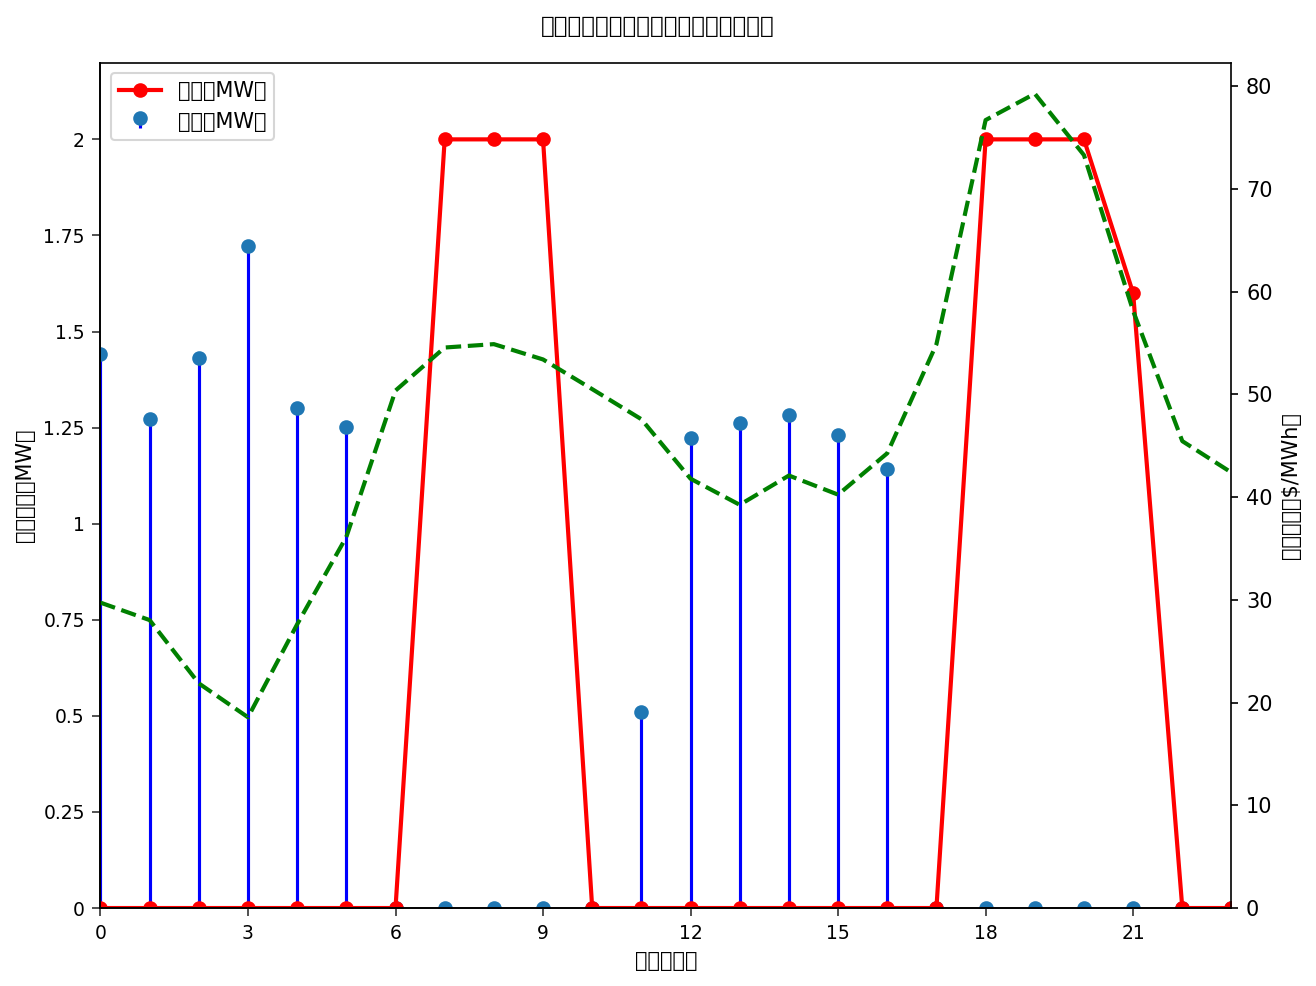

In [8]:
処理 SGPLOT データ=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="充電（MW）";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="放電（MW）";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="価格（$/MWh）";
    XAXIS 見出="時刻（時）" VALUES=(0 から 23 基準 3);
    YAXIS 見出="電池出力（MW）" MIN=0 MAX=2.2;
    y2axis 見出="電力価格（$/MWh）" MIN=0;
    表題 '電池の充放電スケジュールと電力価格';
実行;

## 9. 充電状態の軌跡

蓄えられたエネルギーは、電池が夜間に満たされるにつれて上昇し、各放電ウィンドウを通じて引き下げられ、8 MWh の使用可能容量の上限（点線の基準）を決して超えない。

                                                 KPI要約: 裁定取引とピークシフトの効果                                                  




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


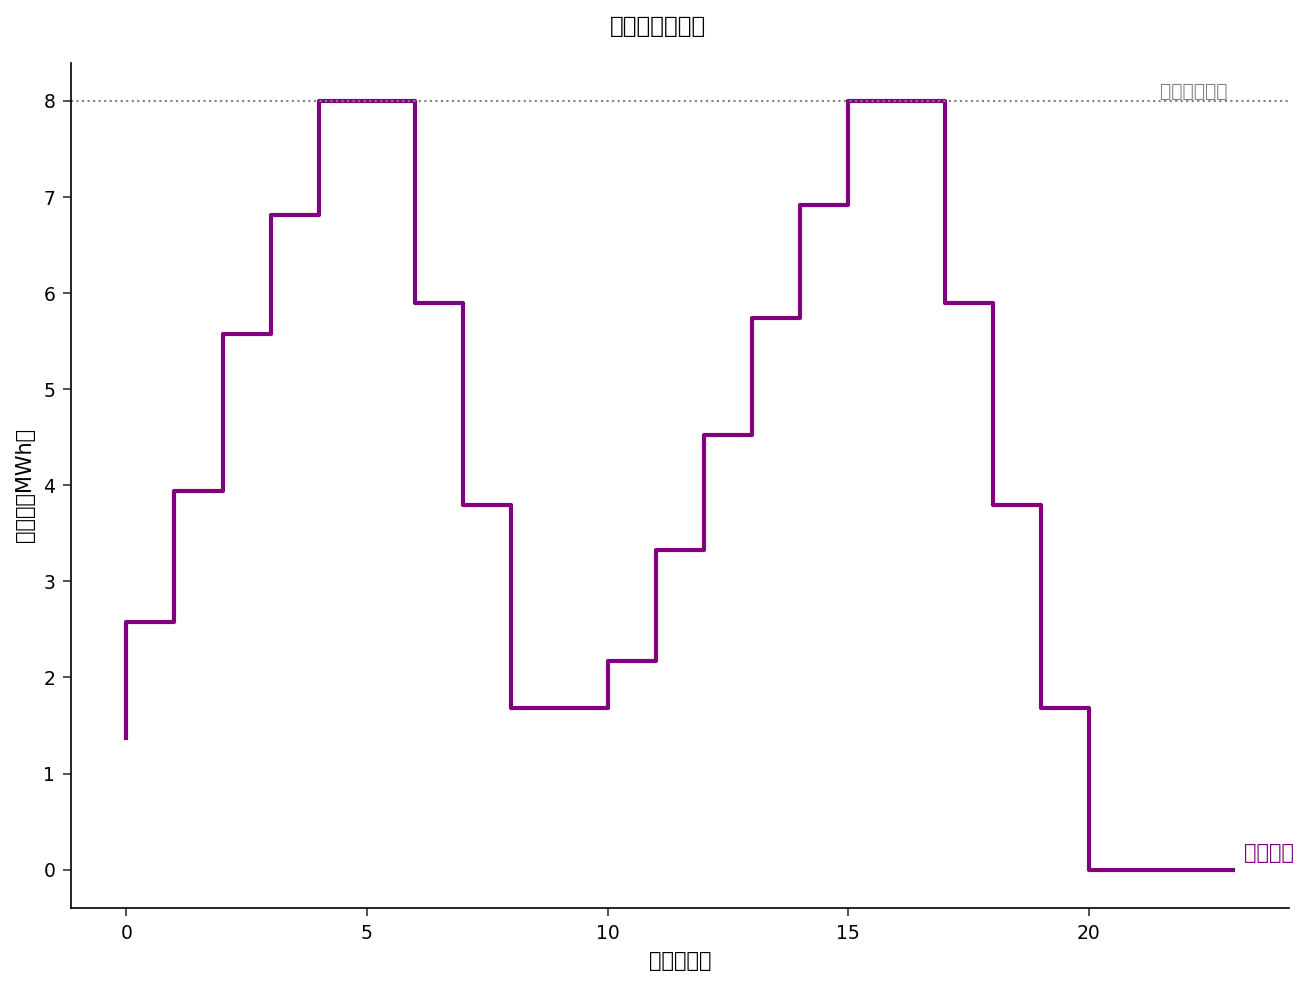

In [9]:
処理 SGPLOT データ=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="蓄電状態";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        見出="利用可能容量";
    XAXIS 見出="時刻（時）";
    YAXIS 見出="蓄電量（MWh）";
    表題 '時間別の蓄電量';
実行;

## 10. 系統受電: ディスパッチ前後

オレンジの線（電池ありの系統受電）は、夕方のランプ（18～21 時）を通じて破線のベースライン負荷を大きく下回る。これがデマンドチャージを下げるピークシェービング効果である。夜間と日中の充電ウィンドウ中には上昇するが、最適化器はそれを平坦な約 3.43 MW の上限で抑え、これは元の 3.59 MW の負荷ピークを*下回った*ままに保たれる。そのため充電は、新たな課金対象最大値を設定することなく安価なエネルギーを購入する。

                                                 KPI要約: 裁定取引とピークシフトの効果                                                  




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


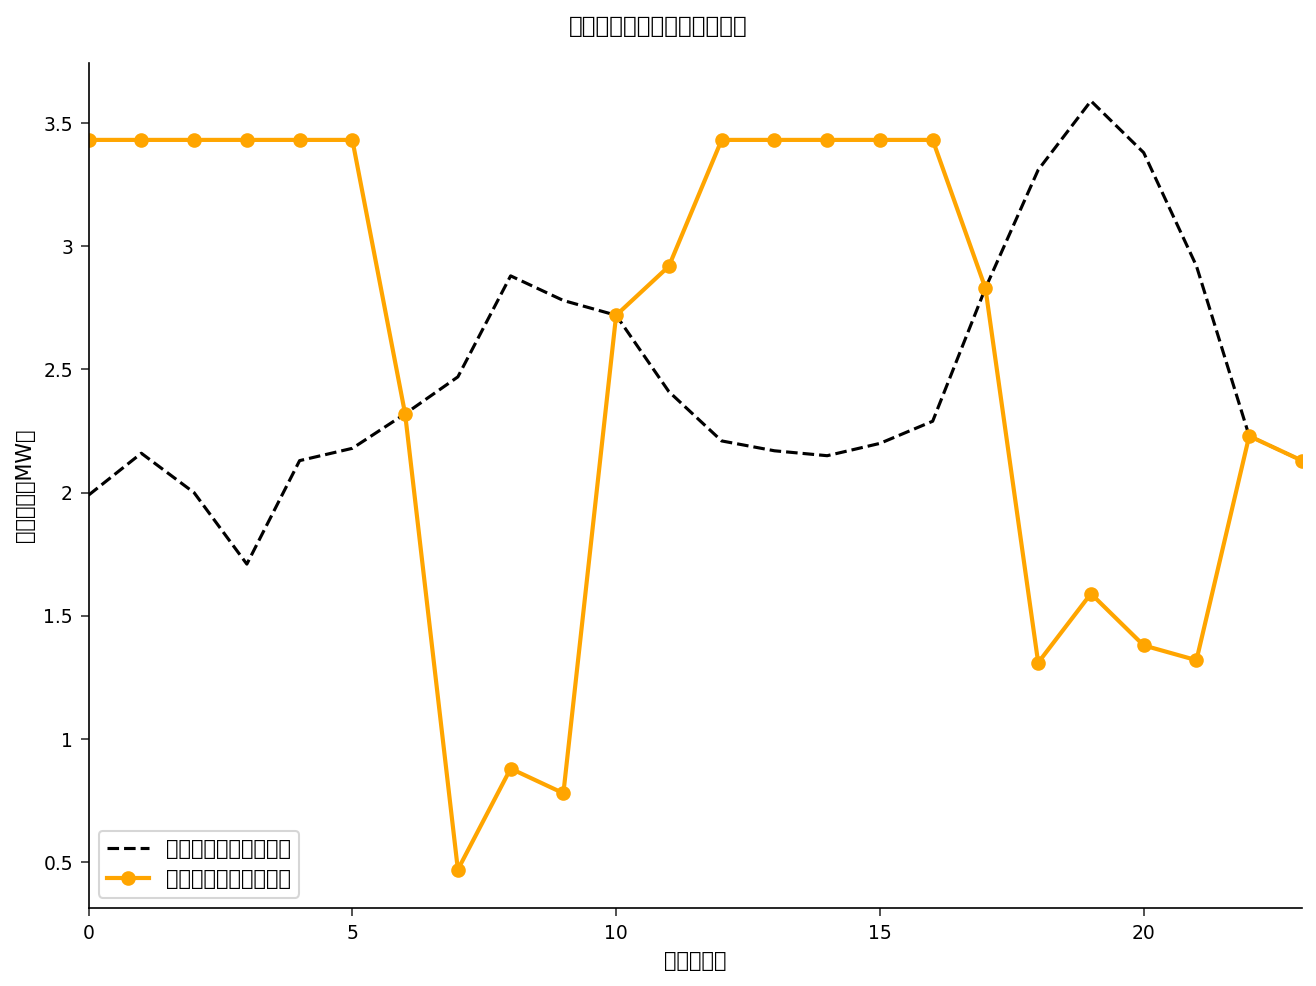

In [10]:
処理 SGPLOT データ=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="施設負荷（電池なし）";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="系統電力（電池あり）";
    XAXIS 見出="時刻（時）";
    YAXIS 見出="系統電力（MW）";
    表題 '電池による系統ピークの削減';
実行;

## 解釈と次のステップ

**モデルが決定したこと。** 往復効率がすべてのサイクルに課税する中でも、最適化器は明確な価値を見出した。最も安価な夜間の時間帯に電池を満たし、朝の価格ピーク（7～9 時）に向けて放電し、日中の価格の谷（11～16 時）で再充電し、そして最も豊かな夕方のピーク（18～21 時）に向けて再び放電した。注目すべきは、夜間の充填中に 2 MW の定格いっぱいではなく、わずか 1.0～1.7 MW で充電した点である。追加された系統受電が受電をその日の負荷ピーク以上に押し上げないよう電力を抑えたのだ。充電状態は、常に 8 MWh の容量と 2 MW の電力制限の両方を尊重した。

**ビジネスケース。** 1 日あたりのエネルギーコストは **\$2,903.78 から \$2,528.43** へと下がり、これは **\$375.34（12.9%）**のアービトラージによる節約にあたる。また、課金対象の系統最大値は **3.59 MW から 3.43 MW**（約 **0.16 MW**）へと下がり、デマンドチャージの項目からさらに **\$18.98** を削った。運用日全体で年換算し、繰り返し発生するデマンドチャージの削減を加えれば、これは蓄電投資を裏付けるたぐいのマージンである。

**なぜ線形計画問題が正しいツールなのか。** ヒューリスティック（「中央値価格を下回れば充電し、上回れば放電する」）は、効率損失、時間をまたいだ容量の結合、そしてデマンドチャージが単一区間に依存するという事実を無視する。それらは夜間に全電力で充電し、課金対象ピークを*引き上げて*しまい、ピークシェービングの価値を破壊するだろう。PROC OPTMODEL はこれらすべてを 1 つの宣言的なモデルで捉え、証明可能な意味で最適なスケジュールを返す。ここではそのスケジュールが、ピークを守るために充電レートを意図的に抑えている。

**モデルの拡張。**

- **より長い期間 / 複数日** — `HOURS` インデックス集合を広げ、日をまたいだサイクリング制限を加える。
- **価格の不確実性** — 複数の価格シナリオにわたって線形計画問題を解き、最初の時間の決定を平均する（ローリング型の確率的方策）。
- **電池の劣化** — スループットのペナルティ項や累積サイクル数への制約を加え、アービトラージと資産寿命を天秤にかける。
- **周波数応答 / 容量市場** — 予備マージン制約を導入し、電池がアービトラージの上に付帯サービス収益を積み重ねられるようにする。

これらはすべて同じ OPTMODEL ブロックへの漸進的な編集である。ここで確立した構造はそのまま引き継がれる。